# Mini-Project: Heart Disease Prediction
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Binary classification on the UCI Heart Disease dataset using Logistic Regression.

Main goals:

- Run preprocessing and EDA on a clinical dataset.
- Train a Logistic Regression model and evaluate with the full metric set.
- Identify which features are most associated with the target.

---

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Load the Dataset

In [2]:
url = 'https://raw.githubusercontent.com/mohitkhyalia1/sos_2026/refs/heads/main/dataset/heart_disease_data.csv'

df = pd.read_csv(url)
print('Shape:', df.shape)
df.head()

Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Preprocessing Checks

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
print('Missing values:', df.isnull().sum().sum())
print('\nTarget distribution:')
print(df['target'].value_counts())
print(f'Positive rate: {df["target"].mean()*100:.1f}%')

Missing values: 0

Target distribution:
target
1    526
0    499
Name: count, dtype: int64
Positive rate: 51.3%


## EDA

In [5]:
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


cp          0.435
thalach     0.423
slope       0.346
restecg     0.134
fbs        -0.041
chol       -0.100
trestbps   -0.139
age        -0.229
sex        -0.280
thal       -0.338
ca         -0.382
exang      -0.438
oldpeak    -0.438
Name: target, dtype: float64


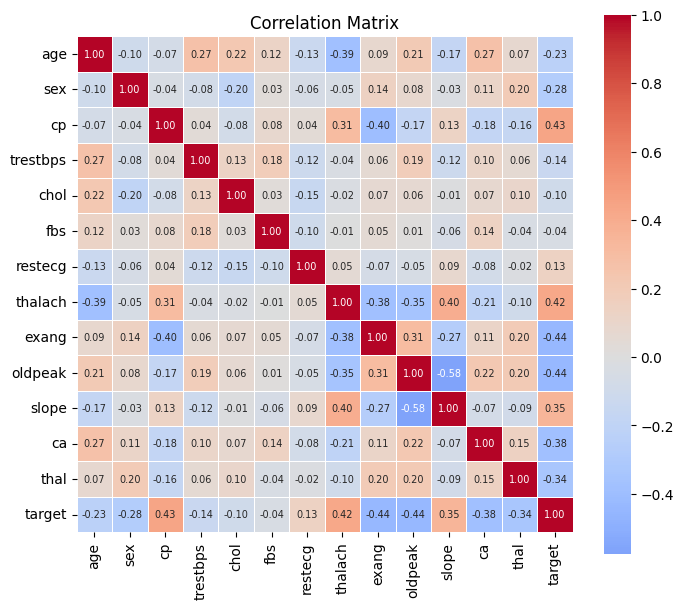

In [6]:
corr = df.corr()['target'].drop('target').sort_values(ascending=False)
print(corr.round(3))

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.4, annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlation Matrix')
plt.show()

**Observation:**
`cp` (chest pain type) and `thalach` (max heart rate achieved) show the strongest positive correlation with target. `exang` and `oldpeak` show the strongest negative correlation.

## Train-Test Split and Scaling

In [7]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}  Test: {X_test_scaled.shape}')

Train: (820, 13)  Test: (205, 13)


## Training the Model

In [8]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

train_preds = model.predict(X_train_scaled)
test_preds = model.predict(X_test_scaled)

print(f'Train accuracy: {accuracy_score(y_train, train_preds):.4f}')
print(f'Test accuracy:  {accuracy_score(y_test, test_preds):.4f}')

Train accuracy: 0.8585
Test accuracy:  0.8049


## Evaluation

In [9]:
print(f'Precision: {precision_score(y_test, test_preds):.4f}')
print(f'Recall:    {recall_score(y_test, test_preds):.4f}')
print(f'F1:        {f1_score(y_test, test_preds):.4f}')
print()
print(classification_report(y_test, test_preds))

Precision: 0.7731
Recall:    0.8762
F1:        0.8214

              precision    recall  f1-score   support

           0       0.85      0.73      0.78       100
           1       0.77      0.88      0.82       105

    accuracy                           0.80       205
   macro avg       0.81      0.80      0.80       205
weighted avg       0.81      0.80      0.80       205



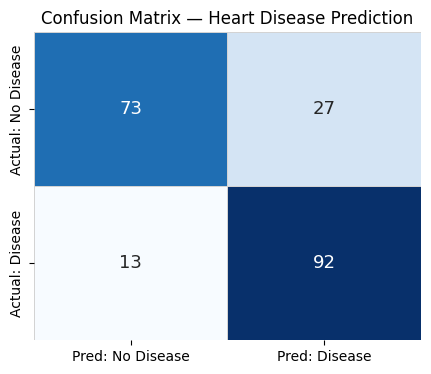

In [10]:
cm = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: No Disease', 'Pred: Disease'],
            yticklabels=['Actual: No Disease', 'Actual: Disease'],
            linewidths=0.5, linecolor='lightgray', cbar=False, annot_kws={'size': 13})
ax.set_title('Confusion Matrix — Heart Disease Prediction')
plt.show()

**Observation:**
False negatives here represent patients predicted healthy who actually have heart disease — the more costly error type in this context. Recall on the disease class is the metric to watch most closely, not just overall accuracy.

## Feature Coefficients

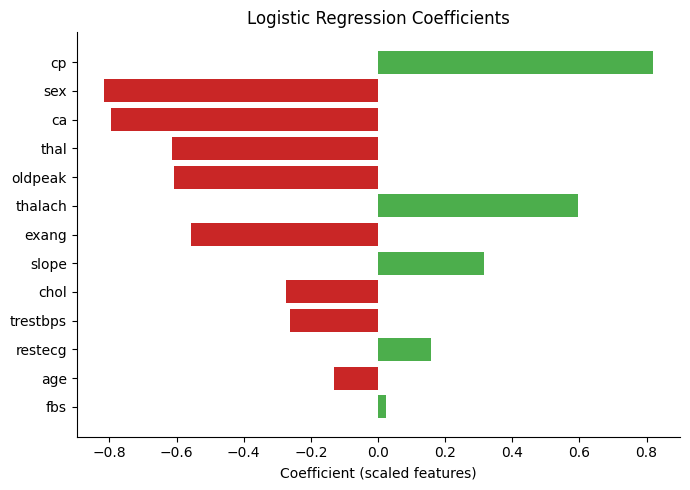

In [11]:
coef_df = pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_[0]})
coef_df = coef_df.sort_values('coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#2CA02C' if c > 0 else '#C00000' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, alpha=0.85)
ax.set_xlabel('Coefficient (scaled features)')
ax.set_title('Logistic Regression Coefficients')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Observation:**
Coefficients are on standardized features, so magnitude is directly comparable across columns — this would not be valid on raw unscaled features, since a feature with naturally larger values could appear more important purely because of its scale.